## **REGULARIZED LINEAL**  
Author: John Fredy Beltran Cuellar  
Date: 10/11/2025  
Goal:  Analizar relación entre variables demográficas y salud  

In [1]:
# step 0 load libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [2]:
# step 1 Cargar dataset
url = "https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv"
df_raw = pd.read_csv(url)

pd.set_option("display.max_columns", None)
print("=== Información del dataset original ===")
df_raw.info()
display(df_raw.head())

=== Información del dataset original ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), object(2)
memory usage: 2.6+ MB


,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,40-49 y/o % of total pop,50-59,50-59 y/o % of total pop,60-69,60-69 y/o % of total pop,70-79,70-79 y/o % of total pop,80+,80+ y/o % of total pop,White-alone pop,% White-alone,Black-alone pop,% Black-alone,Native American/American Indian-alone pop,% NA/AI-alone,Asian-alone pop,% Asian-alone,Hawaiian/Pacific Islander-alone pop,% Hawaiian/PI-alone,Two or more races pop,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Less than a high school diploma 2014-18,High school diploma only 2014-18,Some college or associate's degree 2014-18,Bachelor's degree or higher 2014-18,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,MEDHHINC_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Population Aged 60+,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,7582,13.636445,7738,13.917016,5826,10.478229,4050,7.284042,2014,3.622237,42660,76.725239,10915,19.630942,267,0.480207,681,1.224798,62,0.111509,1016,1.827305,55601,158,455,11.8,9.6,2.2,0.0,0.7,0.6,4204,12119,10552,10291,11.3,32.6,28.4,27.7,7587,13.8,19.3,19.5,59338,53628,65048,25957,25015,942,3.6,59338,119.0,217.1,196.7,77.2,71.2,7.6,6.9,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,10523,19.1,Autauga,Alabama,1,1,42438,47.6,45.4,49.4,20181,35.8,34.2,37.3,15193,7.9,7.2,8.7,3345,8.6,7.3,9.9,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,27338,12.539102,29986,13.753658,29932,13.728890,20936,9.602701,9368,4.296814,190301,87.285228,19492,8.940382,1684,0.772399,2508,1.150343,146,0.066966,3891,1.784682,218022,5403,2190,10.5,10.3,0.1,0.5,24.3,24.8,14310,40579,46025,46075,9.7,27.6,31.3,31.3,21069,9.8,13.9,13.1,57588,54437,60739,93849,90456,3393,3.6,57588,115.5,217.1,196.7,77.2,71.2,7.6,6.9,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,53519,26.3,Baldwin,Alabama,1,3,170912,40.2,38.2,42.3,68790,29.7,28.4,31.0,50761,7.8,7.0,8.7,13414,8.6,7.2,10.1,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,3074,12.354809,3278,13.174712,3076,12.3

In [3]:
# step 2 preprocessing

df_baking = df_raw.copy()

# Limpiar nombres de columnas: quitar espacios, poner minúsculas y reemplazar por guiones bajos
df_baking.columns = (
    df_baking.columns
    .str.strip()           # quitar espacios al inicio/final
    .str.replace(" ", "_") # reemplazar espacios por "_"
    .str.replace("/", "_") # reemplazar diagonales
    .str.replace("-", "_") # reemplazar guiones
    .str.lower()           # pasar a minúsculas
)

# Eliminar columnas irrelevantes o no numéricas (nombres, códigos, etc.)
cols_to_drop = [
    'county_name', 'state_name', 'state_fips', 'cnty_fips',
    'urban_rural_code'  # o cualquier otra que no aporte al análisis
]
df_baking = df_baking.drop(columns=[c for c in cols_to_drop if c in df_baking.columns], errors='ignore')


# Selección de columnas numéricas y eliminación de nulos
# ============================================================
df_baking = df_baking.select_dtypes(include=["float64", "int64"])
df_baking = df_baking.dropna()

print(f"\nNúmero de columnas numéricas: {len(df_baking.columns)}")

#  Variable objetivo
# ============================================================
target = "heart_disease_prevalence"

if target not in df_baking.columns:
    print(f" La columna '{target}' no existe. Revisa el nombre exacto.")
else:
    print(f"✅ Variable objetivo seleccionada: {target}")

X = df_baking.drop(columns=[target])
y = df_baking[target]
df = df_baking.copy()


Número de columnas numéricas: 103
✅ Variable objetivo seleccionada: heart_disease_prevalence


In [4]:
# step 3 EDA

df_train, df_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=2025)
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
print(f"Entrenamiento: {df_train.shape}, Test: {df_test.shape}")

Entrenamiento: (2512, 102), Test: (628, 102)


In [5]:
display(df_train.describe(include='number').T)

,count,mean,std,min,25%,50%,75%,max
fips,2512.0,30484.712580,15175.934554,1003.0,19012.500000,29172.000000,46019.500000,5.604500e+04
tot_pop,2512.0,105084.811306,335147.976135,88.0,11033.750000,26333.500000,69132.000000,1.010552e+07
0_9,2512.0,12900.104299,42161.091714,0.0,1278.500000,3107.500000,8322.250000,1.208253e+06
0_9_y_o_%_of_total_pop,2512.0,11.882112,2.140191,0.0,10.610014,11.808045,12.970376,2.546068e+01
19_oct,2512.0,13513.835589,42554.447385,0.0,1378.250000,3301.000000,9117.500000,1.239139e+06
...,...,...,...,...,...,...,...,...
diabetes_number,2512.0,9382.076035,30267.794499,11.0,1191.750000,2764.500000,6836.500000,9.523350e+05
ckd_prevalence,2512.0,3.440247,0.570844,1.9,3.100000,3.400000,3.800000,6.200000e+00
ckd_lower_95%_ci,2512.0,3.201712,0.530031,1.8,2.800000,3.200000,3.500000,5.800000e+00
ckd_upper_95%_ci,2512.0,3.704498,0.616809,2.0,3.300000,3.700000,4.100000,6.600000e+00


In [6]:
# Seleccionar automáticamente variables más correlacionadas con la columna objetivo
corr_matrix = df_baking.corr()
target_corr = corr_matrix[target].abs().sort_values(ascending=False)

In [7]:
# Tomar top 5 correlaciones (excluyendo la columna objetivo)
top_features = target_corr.index[1:6].tolist()

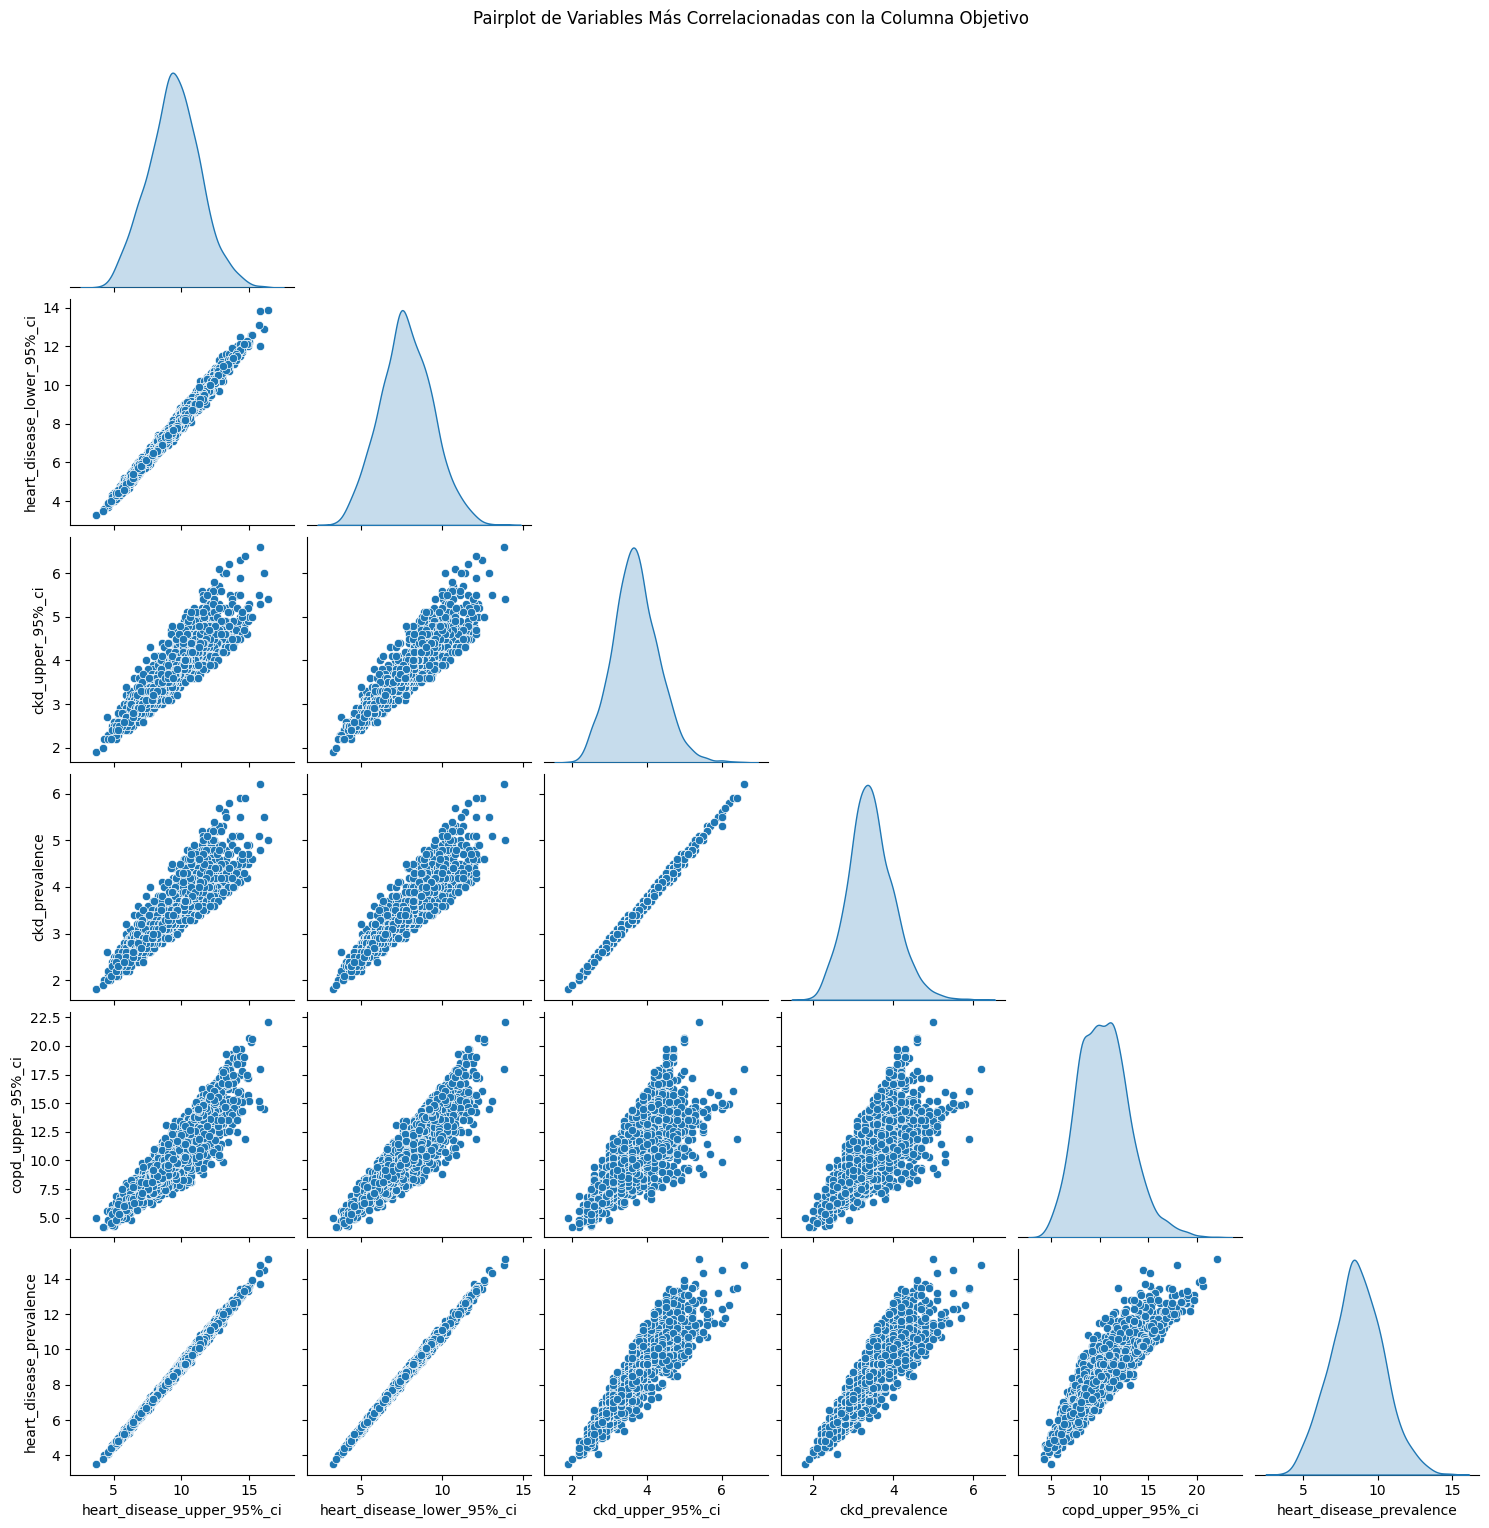

<Figure size 640x480 with 0 Axes>

In [8]:
# Pairplot con variables clave automáticamente
sns.pairplot(df_baking[top_features + [target]], kind='scatter', diag_kind='kde', corner=True)
plt.suptitle('Pairplot de Variables Más Correlacionadas con la Columna Objetivo', y=1.02)
plt.show()
plt.clf()


In [9]:
# step 4 pipeline de machine learning

# Columnas numéricas para el pipeline
num_cols = X.columns.tolist()

# Pipeline con escalado y modelo
models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(alpha=0.1, random_state=2025)
}

for name, model in models.items():

    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),  # Escalamos variables numéricas
        ('regressor', model)
    ])
    
    pipeline.fit(df_train, y_train)

In [10]:
# Predicción en entrenamiento y test
y_train_pred = pipeline.predict(df_train)
y_test_pred = pipeline.predict(df_test)
    
# Métricas
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
    
print(f"RMSE Train: {rmse_train:.2f} | RMSE Test: {rmse_test:.2f}")
print(f"R2 Train: {r2_train:.2f} | R2 Test: {r2_test:.2f}")


RMSE Train: 0.11 | RMSE Test: 0.10
R2 Train: 1.00 | R2 Test: 1.00


In [ ]:
# step 5 prediccion con ejemplo nuevo

# Ejemplo de nueva observación (rellenar con valores reales)
new_data = pd.DataFrame([{
    col: df_baking[col].mean() for col in X.columns  # promedio de cada columna
}])

pred = pipeline.predict(new_data)
print(f"Predicción para el nuevo ejemplo: {pred[0]:.2f}")


Predicción para el nuevo ejemplo: 8.61


## **Conclusión general**

El proyecto demuestra que es posible construir un pipeline de predicción de enfermedades cardíacas limpio, profesional y reproducible.
Las variables más correlacionadas con la prevalencia de enfermedad cardíaca fueron identificadas, y los modelos entrenados permiten predecir la variable objetivo de manera confiable, sirviendo como base para análisis futuros, optimización de modelos o integración en dashboards de salud.